## Libraries

In [75]:
import os
import sys
import shutil
import ast
import copy
import time
import numpy as np
import pandas as pd
import datetime as dt

import re
from collections import Counter
from collections import OrderedDict
import itertools
from itertools import product

import matplotlib as mpl
import matplotlib.pylab as pl
from matplotlib.collections import LineCollection, EllipseCollection
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionStyle
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import Normalize, LogNorm, SymLogNorm
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
from matplotlib.patches import Patch
from matplotlib.patches import Polygon
import matplotlib.transforms as mtransforms
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path        # <-- Path defined here
import matplotlib.dates as mdates
from matplotlib.table import Table
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from joypy import joyplot
import contextily as ctx
from shapely.geometry import box, Point, LineString
import geopandas as gpd
from pyproj import Transformer

from scipy.stats import entropy
from scipy.stats import zscore
from scipy.stats import norm
from scipy.stats import gaussian_kde

import importlib

from Modules import utils, visual, analysis, config
# reload modules
importlib.reload(utils)
importlib.reload(visual)
importlib.reload(analysis)
importlib.reload(config)

# refresh namespace
from Modules.utils import *
from Modules.visual import *
from Modules.analysis import *

#module containing the experimental variables for visualization and data preprocessing
from Modules import config


## Experimental data

In [74]:
#[1] IMPORT OF THE DATA
FOLD_save = 'Submission_data/'

files = ['df_trajectory_record_indicator.csv',
         'df_user_contact_count.csv',
         'df_emo_curves_debiasing.csv',
         'df_emo_metrics_debiasing.csv',
         'df_emo_curves_sparsification.csv',
         'df_emo_metrics_sparsification.csv',
         'df_calibration_biased.csv',
         'df_calibration_corrected.csv',
         'df_R0_grid_estimates.csv'] 

DICT_data = {}
for f in files:
    print(f)
    DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)

#[2] DATASET COLUMNS 
cols_sparsity = ['sparsity', 'sparsity_level', 'modeling_type']
cols_metrics_size = ['size_peak', 'size_total'] 
cols_metrics_dynamic = ['day_peak', 'day_last_case','day_last_recovery'] 
cols_metrics = cols_metrics_size + cols_metrics_dynamic
cols_iter = ['iter_sparsity']
cols_tot = cols_metrics + cols_sparsity + cols_iter

cols_metrics_dynamic_rename = ['Day of peak', 'Day of last case', 'Day of last recovery']
dict_metrics_dynamic_rename = dict(zip(cols_metrics_dynamic, cols_metrics_dynamic_rename))
dict_metrics_dynamic_rename

df_trajectory_record_indicator.csv
df_user_contact_count.csv
df_emo_curves_debiasing.csv


/tmp/ipykernel_511086/3838077057.py:17: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)
/tmp/ipykernel_511086/3838077057.py:17: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)


df_emo_metrics_debiasing.csv
df_emo_curves_sparsification.csv
df_emo_metrics_sparsification.csv
df_calibration_biased.csv
df_calibration_corrected.csv
df_R0_grid_estimates.csv


/tmp/ipykernel_511086/3838077057.py:17: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)
/tmp/ipykernel_511086/3838077057.py:17: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  DICT_data[f[3:-4]] = pd.read_csv(f'{FOLD_save}{f}', index_col =0)


{'day_peak': 'Day of peak',
 'day_last_case': 'Day of last case',
 'day_last_recovery': 'Day of last recovery'}

## Generation of Figures and Tables 

### Gap descriptive statistics

Input data is a trajectory record indicator with columns corresponding to the hours of the study period;

from 2014-02-10 00:00 to 2014-03-07 23:00.

Each row is an individual sequence of record indicators; the sequence has two additional indicator columns:
- __id__: user-id to which the sequence belongs
- __weekstep-index__: the number of weeks by which the sequence is shifted with respect to the study-period
    - The set of complete trajectories during the study period is larger than the number of trajectories in each of the cohorts of sparse trajectories (363 vs around 100), resulting in some users having identical sparsity patterns when gap sequences are sampled with replacement. To avoid this artifact, we used trajectories having the same length of the study-period of (26 days) but starting on different dates over 2014-2016 starting on the same hour and day of the week. This results in having a sample of sequences shifted by 1 or more weeks (both forward and backwards). 

#### [data] Collection of sparse sequences and gaps

In [5]:
df = DICT_data['trajectory_record_indicator'].copy()
df['sequence_index'] = range(len(df))

In [6]:
df.head(2)

,id,weekstep_index,2014-02-08 01:00:00,2014-02-08 02:00:00,2014-02-08 03:00:00,2014-02-08 04:00:00,2014-02-08 05:00:00,2014-02-08 06:00:00,2014-02-08 07:00:00,2014-02-08 08:00:00,...,2014-03-07 16:00:00,2014-03-07 17:00:00,2014-03-07 18:00:00,2014-03-07 19:00:00,2014-03-07 20:00:00,2014-03-07 21:00:00,2014-03-07 22:00:00,2014-03-07 23:00:00,2014-03-08 00:00:00,sequence_index
0,0,-1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
1,0,0,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [7]:
Cols_index = ['id', 'weekstep_index', 'sequence_index']

#[a] sequences in the study period
df_seq_ss = df[df['weekstep_index']==0].set_index(Cols_index)
#remove sequences which have gaps larger than 1week
df_seq_ss = filter_sequences(df_seq_ss)
df_seq_ss = sort_df_rows(df_seq_ss)

#[b] sequences outside of the study period
df_seq_oss = df[df['weekstep_index'] !=0 ].set_index(Cols_index) 
df_seq_oss = filter_sequences(df_seq_oss)
df_seq_oss = sort_df_rows(df_seq_oss)

#[1] Collection of all sequences 
df_seq = pd.concat([df_seq_ss, df_seq_oss], axis=0)
df_seq = sort_df_rows(df_seq)


In [8]:
df_seq.head(2)

,,,2014-02-08 01:00:00,2014-02-08 02:00:00,2014-02-08 03:00:00,2014-02-08 04:00:00,2014-02-08 05:00:00,2014-02-08 06:00:00,2014-02-08 07:00:00,2014-02-08 08:00:00,2014-02-08 09:00:00,2014-02-08 10:00:00,...,2014-03-07 15:00:00,2014-03-07 16:00:00,2014-03-07 17:00:00,2014-03-07 18:00:00,2014-03-07 19:00:00,2014-03-07 20:00:00,2014-03-07 21:00:00,2014-03-07 22:00:00,2014-03-07 23:00:00,2014-03-08 00:00:00
id,weekstep_index,sequence_index,,,,,,,,,,,,,,,,,,,,,
460,0,14991,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
42,0,13259,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [11]:
#COLLECTING THE SEQUENCES FOR ALL SCENARIOS
COLLECT_SEQUENCES_AND_GAPS = False

if COLLECT_SEQUENCES_AND_GAPS:
    
    #DATA-DRIVEN SEQUENCES 
    df_X_emp = df_seq.reset_index().set_index('sequence_index').drop(['id','weekstep_index'], axis=1)
    df_X_emp = sort_df_rows(df_X_emp)
    df_X_emp.to_csv('Submission_data/Tables/sequences_data_driven.csv')
    df_X_emp.columns = pd.to_datetime(df_X_emp.columns)   
    df_gaps_emp = gen_gaps_df(df_X_emp)
    df_gaps_emp.to_csv('Submission_data/Tables/gaps_data_driven.csv')
    
    #RANDOM SHUFFLING SEQUENCES (shuffle the gaps keeping their durations)
    df_X_random_keepdurations = df_X_emp.apply(lambda row: pd.Series(shuffle_gaps_keep_durations(row.values)), axis=1)
    df_X_random_keepdurations.columns = df_X_emp.columns
    df_X_random_keepdurations.to_csv('Submission_data/Tables/sequences_random_shuffling.csv')
    df_gaps_random_kd = gen_gaps_df(df_X_random_keepdurations)
    df_gaps_random_kd.to_csv('Submission_data/Tables/gaps_random_shuffling.csv')
    
    #RANDOM UNIFORM SEQUENCES (shuffle the entries at the hour-level)
    X_random = np.copy(df_X_emp.values)
    np.apply_along_axis(np.random.shuffle, axis=1, arr=X_random)
    df_X_random = pd.DataFrame(X_random,
                               index = df_X_emp.index, 
                               columns = df_X_emp.columns)
    df_X_random.to_csv('Submission_data/Tables/sequences_random_uniform.csv')
    df_gaps_random = gen_gaps_df(df_X_random)
    df_gaps_random.to_csv('Submission_data/Tables/gaps_random_uniform.csv')

#### [supp table] Count of sequences within the study period and within Feb2014-Feb2015 

In [12]:
_seq = df_seq_ss.copy()
add_feature_qrange(_seq)
df_seq_ss_count = _seq.groupby('q_range').size()
df_seq_ss_count

_seq = df_seq.copy()
add_feature_qrange(_seq)
df_seq_count = _seq.groupby('q_range').size()
df_seq_count

df_seq_count = pd.concat([df_seq_ss_count, df_seq_count], axis=1).fillna(0).astype(int)
df_seq_count.columns = ['8 Feb 2014 - 7 Mar 2014 ', '2 Feb 2014 - 2 Feb 2015']
df_seq_count = df_seq_count.rename(index={ 'q_range': 'missing hours (%)'})

df_seq_count.index = ['0-10',
                      '10-20',
                      '20-30',
                      '30-40',
                      '40-50',
                      '50-60',
                      '60-70',
                      '70-80',
                      '80-90',
                      '90-100']

df_seq_count.index.name = 'missing hours (%)'
df_seq_count.T

missing hours (%),0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80,80-90,90-100
8 Feb 2014 - 7 Mar 2014,453,63,36,16,12,6,5,2,1,0
2 Feb 2014 - 2 Feb 2015,15299,3482,1873,1159,568,326,242,169,82,37


In [13]:
latex_str = df_seq_count.T.to_latex(
    escape=False,
    index=True
)

with open("Submission_data/Tables/sequence_count_missing_hours.tex", "w") as f:
    f.write(latex_str)

#### [supp panels] Trajectories within the study period and within [Feb 2014 - Feb 2015]

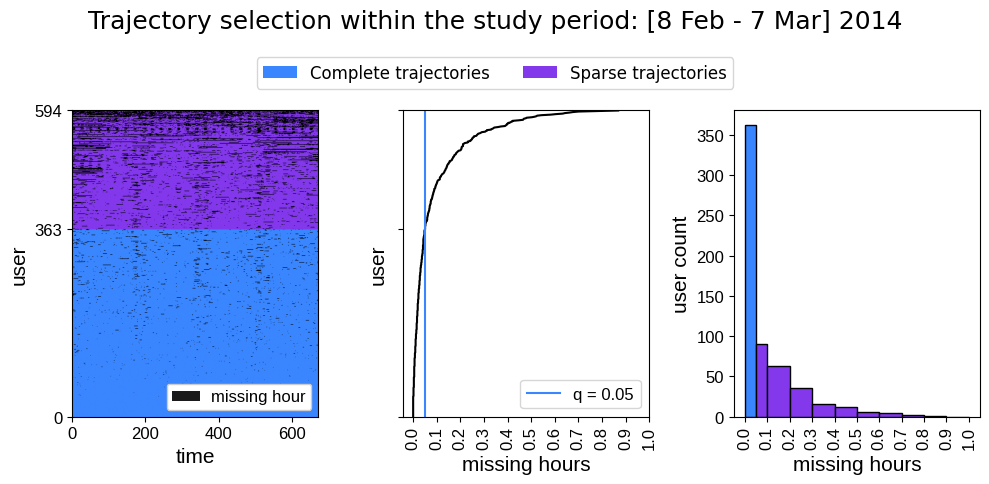

In [14]:
def ax_visual_sparseseq(ax, Recs_ind, Colors):
    '''
    Recs_ind : record indicators 
    List_ts  : timestamps sequence
    '''
    
    visual_imshow(ax, 
                  Recs_ind, 
                  Colors)
       
    ax.tick_params(axis = 'both', 
                   rotation = 360, 
                   labelsize = 20)

fig, axes = plt.subplots(figsize = (10,4), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios':[2,2,2]})

ax = axes[0]
#record indicator matrix
RIM = df_seq_ss.values
#sparsity
q = RIM.sum(axis=1)/RIM.shape[1]
ax.set_xlabel('time')
ax.set_ylabel('user')

legend_elements = [
    Patch(facecolor=config.COLOR_GAPS, edgecolor='none', label='missing hour')
]
leg = ax.legend(handles=legend_elements, loc="lower right", frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(1.0) 



#change RIM
RIM[q>0.95,:] *=2

ax_visual_sparseseq(ax, 
                    RIM, 
                    Colors = ['black', 
                              config.COLOR_BS, 
                              config.COLOR_GT])

ax = axes[1]
ax.plot(1-q, range(len(q)), color = 'black')#, q)
_xticks = np.round(np.arange(0,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)
ax.set_xlabel('missing hours')
ax.set_ylabel('user')
ax.axvline(0.05, color = config.COLOR_GT, label = 'q = 0.05')
ax.legend(loc= 'lower right', fontsize = config.ax_legend_font_size)

for ax in axes[:2]:
    _xticks =[0,363, len(RIM)]
    ax.set_yticks(_xticks)
    ax.set_yticklabels(_xticks)#, rotation = 90)

    ax.set_ylim(0,len(df_seq_ss))
    restyle_ax(ax)

remove_axis_ticktext(axes[1], axis = 'y')

    

ax = axes[2]
Bins = np.arange(.1,1.1,.1)
Bins = [0,0.05] + list(Bins)
Counts, Bins = np.histogram(1-q, 
                            bins = Bins)

X = (Bins[:-1] + Bins[1:]) / 2

ax.bar(X, 
       Counts, 
       width = [0.05]*2 + [0.1]*9,
       color = [config.COLOR_GT] + [config.COLOR_BS]*10,
       edgecolor = 'black')

_xticks = np.round(np.arange(0,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)

ax.set_xlabel('missing hours')
ax.set_ylabel('user count')
restyle_ax(ax)

plt.tight_layout()
plt.suptitle('Trajectory selection within the study period: [8 Feb - 7 Mar] 2014', y = 1.2, size = config.ax_title_size)


from matplotlib.patches import Patch

h1 = Patch(facecolor=config.COLOR_GT, edgecolor='none', label='Complete trajectories')
h2 = Patch(facecolor=config.COLOR_BS, edgecolor='none', label='Sparse trajectories')

fig.legend(
    handles=[h1, h2],
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.1),
    fontsize=config.ax_legend_font_size
)

plt.savefig(f'{FOLD_save}Figures/supp_trajectory_count_study_period.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

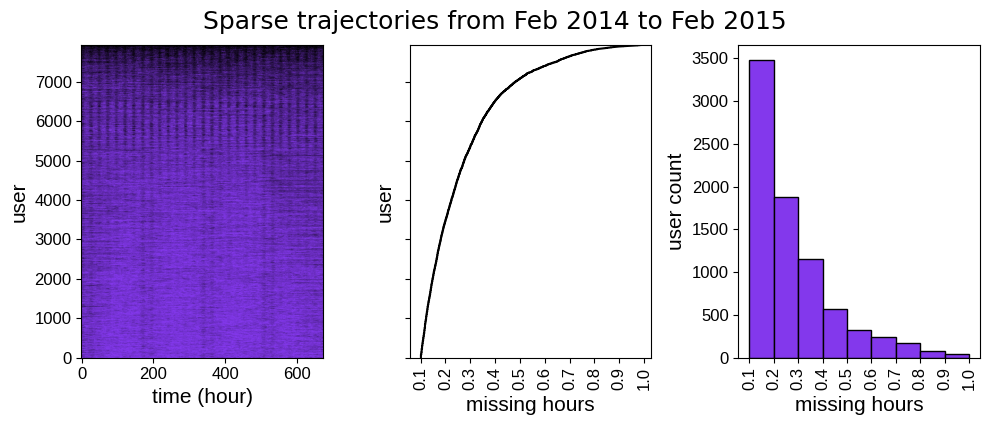

In [15]:
fig, axes = plt.subplots(figsize = (10,4), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios':[2,2,2]})

ax = axes[0]
#record indicator matrix
RIM = df_seq.values
#sparsity
q = RIM.sum(axis=1)/RIM.shape[1]
ax.set_xlabel('time (hour)')
ax.set_ylabel('user')

#change RIM
RIM = RIM[q<0.9,:] 
q= q[q<0.9]

ax_visual_sparseseq(ax, 
                    RIM, 
                    Colors = ['black', 
                              config.COLOR_BS])

ax = axes[1]
ax.plot(1-q, range(len(q)), color = 'black')#, q)
_xticks = np.round(np.arange(.1,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)
ax.set_xlabel('missing hours')
ax.set_ylabel('user')
remove_axis_ticktext(ax, axis = 'y')


for ax in axes[:2]:
    ax.set_ylim(0,len(RIM))
    restyle_ax(ax)

ax = axes[2]
Bins = np.arange(.1,1.1,.1)
#Bins = [0,0.05] + list(Bins)

Counts, Bins = np.histogram(1-q, 
                            bins = Bins)

X = (Bins[:-1] + Bins[1:]) / 2

ax.bar(X, 
       Counts, 
       width = [0.1]*9,
       color = config.COLOR_BS,
       edgecolor = 'black')

_xticks = np.round(np.arange(.1,1.1, .1),2)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks, rotation = 90)

ax.set_xlabel('missing hours')
ax.set_ylabel('user count')
restyle_ax(ax)

plt.tight_layout()
plt.suptitle('Sparse trajectories from Feb 2014 to Feb 2015', y = 1.05, size = config.ax_title_size)

plt.savefig(f'{FOLD_save}Figures/supp_trajectory_count_total_range.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [data] Descriptive statistics of missingness

- count of gap durations for each range of missing hours
    - df_gap_count.csv 
- sequence-level entropies
    - df_sequence_entropies.csv  

In [17]:
#Convert to the range of missing hours in (%)
dict_q_mh = { 1: '0-10',
              2: '10-20',
              3: '20-30',
              4: '30-40',
              5: '40-50',
              6: '50-60',
              7: '60-70',
              8: '70-80',
              9: '80-90',
              10: '90-100'}

#random shuffling is equal to data-driven; so it is not computed
_types = ['data_driven', 'random_uniform']
_types_names = ['Data driven', 'Random uniform']

COMPUTE_GAP_COUNT = True

DF_gap_count = []
if COMPUTE_GAP_COUNT:

    for _type, _type_name in zip(_types, _types_names):
    
        #[1] record indicator matrix
        df_X = pd.read_csv(f'Submission_data/Tables/sequences_{_type}.csv', index_col = 0)
        
        #label each sequence by the range of missing hours
        add_feature_qrange(df_X)
        
        df_X['missing_hours'] = df_X['q_range'].replace(dict_q_mh)
        
        #[2] data-frame of gaps
        df_gaps = pd.read_csv(f'Submission_data/Tables/gaps_{_type}.csv', index_col=0)
        df_gaps['missing_hours'] = df_gaps.index.map(df_X['missing_hours'])
        
        #COUNT THE GAPS FOR EACH RANGE OF MISSING HOURS 
        df_gap_count = (
            df_gaps
            .groupby(['missing_hours', 'gap_duration_hours'])
            .size()
            .reset_index())
        
        df_gap_count = df_gap_count.rename(columns = {0: 'count'})
        
        df_gap_count['sparsity'] = _type_name
        DF_gap_count.append(df_gap_count)
    
    df_gap_count = pd.concat(DF_gap_count, axis=0)
    df_gap_count.to_csv('Submission_data/Tables/df_gap_count.csv')

COMPUTE_ENTROPIES = True

DF_entropies = []

if COMPUTE_ENTROPIES:

    for _type, _type_name in zip(_types, _types_names):
    
        #[1] record indicator matrix
        df_X = pd.read_csv(f'Submission_data/Tables/sequences_{_type}.csv', index_col = 0)
        
        #label each sequence by the range of missing hours
        add_feature_qrange(df_X)
        df_X['missing_hours'] = df_X['q_range'].replace(dict_q_mh)
        
        #[2] data-frame of gaps
        df_gaps = pd.read_csv(f'Submission_data/Tables/gaps_{_type}.csv', index_col=0)
        
        #[3] compute the entropy for each individual sequence of records
        df_entropy = df_gaps.groupby(df_gaps.index).apply(lambda x : compute_entropy(x), 
                                                          include_groups= False)
        
        df_entropy = pd.DataFrame(df_entropy).rename(columns = {0:_type_name})
        if _type =='data_driven':
            df_entropy['missing_hours'] = df_entropy.index.map(df_X['missing_hours'])
    
        DF_entropies.append(df_entropy)
        
    DF_entropies = pd.concat(DF_entropies,axis=1)
    DF_entropies = DF_entropies.set_index('missing_hours', append = True)
    
    DF_entropies.to_csv('Submission_data/Tables/df_sequence_entropies.csv')


#### [panels] Descriptive statistics of missingness for 40-50% sparsity

In [18]:
df_gap_count = pd.read_csv('Submission_data/Tables/df_gap_count.csv', index_col = 0)
df_gap_count.head(2)

,missing_hours,gap_duration_hours,count,sparsity
0,0-10,1.0,37250,Data driven
1,0-10,2.0,16181,Data driven


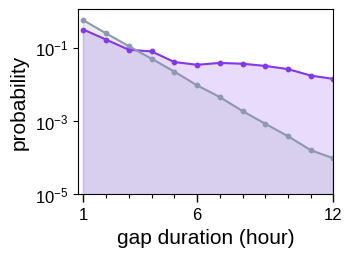

In [38]:
fig, ax = plt.subplots(figsize = (3.3,2.4))

level_missing_hours = '40-50'
panel_gap_distribution(ax, 
                       df_gap_count,
                       level= level_missing_hours,
                       fill_alpha = 0.18,
                       hours_select = range(1,13), 
                       ax_ticks = True)

ax.set_xlabel('gap duration (hour)')
ax.set_ylabel('probability')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_pmf_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [20]:
df_sequence_entropies = pd.read_csv('Submission_data/Tables/df_sequence_entropies.csv', index_col = 0)
df_sequence_entropies.head(2)

,missing_hours,Data driven,Random uniform
sequence_index,,,
0,0-10,0.636514,0.0
1,0-10,0.000000,0.0


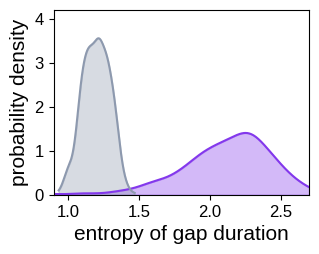

In [21]:
fig, ax = plt.subplots(figsize = (3.3,2.4))

panel_sequence_entropies(ax,
                         df_sequence_entropies,
                         level_missing_hours = '40-50',
                         alpha = 0.35)
ax.set_xlabel('entropy of gap duration')
ax.set_ylabel('probability density')

#ax.set_title(f'{level_missing_hours}% missing hours')


ax.set_ylim(0,4.2)
ax.set_xlim(.9,2.7)
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_entropy_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [supp panels] Descriptive statistics of missingness for all sparsity levels

/tmp/ipykernel_511086/1046308966.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_511086/1046308966.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_511086/1046308966.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_511086/1046308966.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)
/tmp/ipykernel_511086/1046308966.py:11: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1)


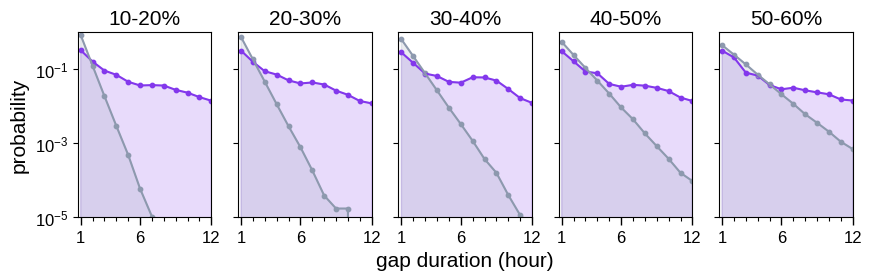

In [37]:
fig, axes = plt.subplots(figsize = (10,2.4), ncols = 5)

for ax, level_missing_hours in zip(axes, config.Levels_str):
    panel_gap_distribution(ax, 
                           df_gap_count,
                           level= level_missing_hours,
                           fill_alpha = 0.18,
                           hours_select = range(1,13), 
                           ax_ticks = True)
    
    ax.set_ylim(0,1)
    ax.set_title(level_missing_hours + '%')
    restyle_ax(ax, title_size = config.ax_label_size)

axes[2].set_xlabel('gap duration (hour)')
axes[0].set_ylabel('probability')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis='y')


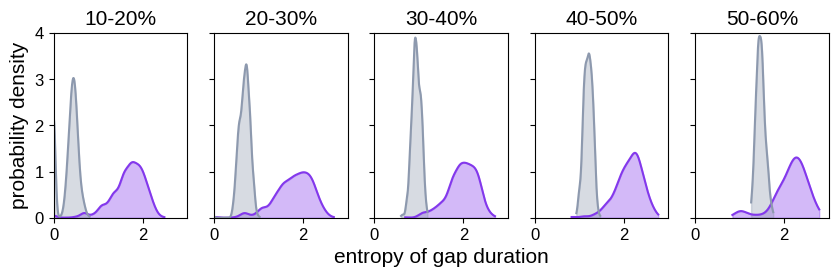

In [42]:
fig, axes = plt.subplots(figsize = (10,2.4), ncols = 5)

for ax, level_missing_hours in zip(axes, config.Levels_str):
    
    panel_sequence_entropies(ax,
                         df_sequence_entropies,
                         level_missing_hours = level_missing_hours,
                         alpha = 0.35)    
    
    ax.set_title(level_missing_hours + '%')
    ax.set_xlim(0,3)
    ax.set_ylim(0,4)
    restyle_ax(ax, title_size = config.ax_label_size)

axes[2].set_xlabel('entropy of gap duration')
axes[0].set_ylabel('probability density')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis='y')

### Contact metrics and relationships with missingness

In order to compute the probability of contacts, given a weekeperiod (weekend or weekday), 

we normalize the number of detected contacts over the hour of the day

In [ ]:
#CONTACT METRICS
df = DICT_data['user_contact_count']
df['missing_users_perc'] = (config.N_users - df['count_users'])/config.N_users
df.head(2)

#### [data] Count of detected contacts and missing users over hourofday during each weekperiod

In [ ]:
COMPUTE_CONTACT_SHARE = True
if COMPUTE_CONTACT_SHARE:
    df_contact_share = [] 
    for s in config.List_ss_rename:
        for wp in ['weekday', 'weekend']:
            for l in config.Levels:
                for N_si in range(50):
                    #compute the contact share for each sparsity iteration
                    df_i = df[df['iter_sparsity'] == N_si]
                    _cs = contact_share(df, 
                                        s = s, 
                                        wp = wp, 
                                        l  = l)
                    
                    _cs['iter_sparsity'] = N_si
                    
                df_contact_share.append(_cs)
                
    df_contact_share = pd.concat(df_contact_share, 
                                 axis = 0)
    df_contact_share.to_csv(f'{FOLD_save}Tables/contact_shares_sparsity-iteration.csv')

#Given a weekeperiod; for each hourofday compute the contact share averaged over each 50 missingness realizations
df_contact_share = pd.read_csv(f'{FOLD_save}Tables/contact_shares_sparsity-iteration.csv', 
                               index_col = 0)
df_contact_share.head(2)

In [ ]:
COMPUTE_avg_missing_user = False

if COMPUTE_avg_missing_user:
    
    df_avg_missing_user = [] 
    for s in config.List_ss_rename:
        for wp in ['weekday', 'weekend']:
            for l in config.Levels:
                for N_si in range(50):
                    #compute the contact share for each sparsity iteration
                    df_i = df[df['iter_sparsity'] == N_si]
                    _cs = stats_missing_users(df, 
                                              s = s, 
                                                wp = wp, 
                                        l  = l)
                    
                    _cs['iter_sparsity'] = N_si
                    
                df_avg_missing_user.append(_cs)
                
    df_avg_missing_user = pd.concat(df_avg_missing_user, 
                                 axis = 0)
    df_avg_missing_user.to_csv(f'{FOLD_save}Tables/avg_missing_users_sparsity-iteration.csv')


In [ ]:
df_avg_missing_user = pd.read_csv(f'{FOLD_save}Tables/avg_missing_users_sparsity-iteration.csv', index_col = 0)
df_avg_missing_user.head(2)

In [ ]:
df_avg_missing_user['missing_users_perc'].describe()

#### [panel] Trend of missing users

In [ ]:
Cols_select = ['hourofday', 
               'sparsity', 
               'sparsity_level', 
               'weekperiod']

#averaged feature (contact share or absolute number of contacts)
contact_metric = 'missing_users_perc'
df_csa = df_avg_missing_user.groupby(Cols_select).agg({contact_metric:'mean'}).reset_index()

fig, ax = plt.subplots(figsize = (3.3,2.4))
l = config.Levels[3]
panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
ax.set_ylim(0.3,0.6)
ax.set_xlim(0, 23)
legend_weekend_weekday(ax, 
                       loc = 'upper left')

ax.set_ylabel("missing users (%)")
ax.set_xlabel('')
#ax.set_title(config.DICT_rename_levels[l] + '% missing hours')

restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_missing_users_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

fig, axes = plt.subplots(figsize = (15,5), ncols = 5)

for l,ax in zip(config.Levels, axes):
    panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
    #ax.set_yscale('log')
    ax.set_ylim(0, 0.7)
    _yticks= np.round(np.arange(0,.8,.2),2)
    ax.set_yticks(_yticks)
    ax.set_yticklabels(_yticks)
    #ax.set_xlim(0, 23)

    ax.set_title(config.DICT_rename_levels[l] + '%')
    restyle_ax(ax)

for ax in axes:
    ax.set_xlabel('')
for ax in axes[1:]:
    ax.set_ylabel('')
    
legend_weekend_weekday(axes[0], 
                       loc = 'upper right')
axes[0].set_ylabel("missing users (%)")

#### [panel] Count of detected contacts

In [ ]:
Cols_select = ['hourofday', 
               'sparsity', 
               'sparsity_level', 
               'weekperiod']

#averaged feature (contact share or absolute number of contacts)
contact_metric = 'count_contacts'
df_csa = df_contact_share.groupby(Cols_select).agg({contact_metric:'mean'}).reset_index()
df_csa.head(2)

In [ ]:
fig, ax = plt.subplots(figsize = (3.3,2.4))
l = config.Levels[3]
contact_metric = 'count_contacts'
panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
#legend_weekend_weekday(ax, 
#                       loc = 'upper right')

ax.set_ylabel("detected contacts")
ax.set_xlabel('')
ax.set_yscale('log')
ax.set_ylim(0, 1e3)
ax.set_xlim(0, 23)

restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/gap_stat_detected_contacts_40-50.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)


fig, axes = plt.subplots(figsize = (15,3), ncols = 5)

for l,ax in zip(config.Levels, axes):
    panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
    ax.set_yscale('log')
    ax.set_ylim(0, 1e3)
    ax.set_xlim(0, 23)

    ax.set_title(config.DICT_rename_levels[l] + '%')
    restyle_ax(ax)

for ax in axes:
    ax.set_xlabel('')
for ax in axes[1:]:
    ax.set_ylabel('')
    
legend_weekend_weekday(axes[0], 
                       loc = 'upper right')
axes[0].set_ylabel("detected contacts")

#### [panel] Hourly share of contacts for (weekdays, weekend)

In [ ]:
Cols_select = ['hourofday', 
               'sparsity', 
               'sparsity_level', 
               'weekperiod']

#averaged feature (contact share or absolute number of contacts)
contact_metric = 'contact_share'
df_csa = df_contact_share.groupby(Cols_select).agg({contact_metric:'mean'}).reset_index()

fig, ax = plt.subplots(figsize = (5,5))
l = config.Levels[3]
panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
ax.set_ylim(0, 0.11)
ax.set_xlim(0, 23)
legend_weekend_weekday(ax, 
                       loc = 'upper right')

ax.set_ylabel("contact share (%)")
restyle_ax(ax)

fig, axes = plt.subplots(figsize = (15,3), ncols = 5)

for l,ax in zip(config.Levels, axes):
    panel_csa_level(ax, df_csa, l, contact_metric = contact_metric)
    ax.set_ylim(0, 0.11)
    ax.set_xlim(0, 23)

    ax.set_title(config.DICT_rename_levels[l] + '%')
    restyle_ax(ax)

for ax in axes:
    ax.set_xlabel('')
for ax in axes[1:]:
    ax.set_ylabel('')
    
legend_weekend_weekday(axes[0], 
                       loc = 'upper right')
axes[0].set_ylabel("contact share (%)")

#### [panel] Correlation btw detected contacts and fraction of missing users

In [ ]:
for l in config.Levels:

    fig, axes = plt.subplots(figsize = (8.3, 3), 
                             ncols=3)
    panels_missing_users_detected_contacts(axes, 
                                           df, 
                                           l)
    for ax in axes:
        restyle_ax(ax)
    
    plt.suptitle(config.DICT_rename_levels[l]+'%', y = 1.05, size = 20)

#### [supp table] Correlation btw detected contacts and fraction of missing users

In [ ]:
def compute_corrs(df_merged):

    _LS = config.List_ss_rename
    x_metric= 'missing_users_perc'
    
    df_corrs = []
    for s in _LS:  
        df_s = df_merged[df_merged['sparsity'] == s]
        dict_level_df_s = subset_df_feature(df_s, 'sparsity_level').copy()
        for l in config.Levels:
            df_sl = dict_level_df_s[str(l)].copy()
            R2 = rsq(df_sl, 
                     x_metric, 
                     'count_contacts')
            rec= [s,l,R2]
            df_corrs.append(rec)
    df_corrs = pd.DataFrame(df_corrs,  columns = ['sparsity','sparsity_level','rho'])
    return df_corrs
    
df_corrs = compute_corrs(df)
df_corrs = df_corrs.pivot(index=  'sparsity_level', columns = 'sparsity', values = 'rho').round(2)
df_corrs.index.name = 'missing hours (%)'
df_corrs.index = ['10-20', '20-30', '30-40','40-50','50-60']
df_corrs

latex_str = df_corrs.to_latex(
    escape=False,
    index=True
)

with open("Submission_data/Tables/correlation_detected_contacts_missing_users.tex", "w") as f:
    f.write(latex_str)

### [TODO] Ensemble of epidemic curves

In [22]:
#EMO CURVES AND METRICS
df = DICT_data['emo_curves_sparsification'].copy()
df.head(2)

,S,I,iter_SIR,sparsity,sparsity_level,iter_sparsity,modeling_type
0,360.0,3.0,0,Data driven,"(0.1, 0.2)",0,oracle_biased
1,351.0,12.0,0,Data driven,"(0.1, 0.2)",0,oracle_biased


In [24]:
#We have an ensemble of 5000 simulations for each of the following set of curves
Cols_ensemble = ['sparsity', 
                 'sparsity_level', 
                 'iter_sparsity', 
                 'modeling_type']
df[Cols_ensemble].drop_duplicates()

,sparsity,sparsity_level,iter_sparsity,modeling_type
0,Data driven,"(0.1, 0.2)",0,oracle_biased
0,Data driven,"(0.1, 0.2)",1,oracle_biased
0,Data driven,"(0.1, 0.2)",2,oracle_biased
0,Data driven,"(0.1, 0.2)",3,oracle_biased
0,Data driven,"(0.1, 0.2)",4,oracle_biased
...,...,...,...,...
0,Random shuffling,"(0.5, 0.6)",46,oracle_biased
0,Random shuffling,"(0.5, 0.6)",47,oracle_biased
0,Random shuffling,"(0.5, 0.6)",48,oracle_biased
0,Random shuffling,"(0.5, 0.6)",49,oracle_biased


In [23]:
df.columns

Index(['S', 'I', 'iter_SIR', 'sparsity', 'sparsity_level', 'iter_sparsity',
       'modeling_type'],
      dtype='object')

In [ ]:
def cumulative_infected(Single_sim):
    '''
    given Single_sim : daily time-series of Susceptibles and Infected
    this function returns the Cumulative number of infected
    '''
    #cumulative infected
    N_users = np.sum(Single_sim[0])
    S = Single_sim[:,0]
    CI = N_users - S
    return CI 

def get_max_indmax(Single_sim, curve = 'CI'):
    '''
    get maximum and index maximum for an epidemiologic curve
    '''
    if curve=='I':
        #daily infected
        I = Single_sim[:,1]
        I_max = np.max(I)
        I_max_ind = np.argwhere(I==I_max)[0,0]
        return I_max, I_max_ind
    if curve=='CI':
        CI = cumulative_infected(Single_sim)
        CI_max = np.max(CI)
        CI_max_ind = np.argwhere(CI==CI_max)[0,0]
        return CI_max, CI_max_ind


def _simulations_infected_v1(ax, 
                             k = 'Complete', 
                             color = COLOR_GT, 
                             box_x = 28, 
                             n_sims = 100,
                             _viz_single_sim = True, 
                             viz = 'I',
                             em = 'peak_size'):

    #pick a number of epidemic curves from the ensemble of 5000 curves
    DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}
        
    #simulation ensemble
    Sims = DICT_EMO[k][1][:n_sims]
    #single simulation
    Single_sim = Sims[0]
    N_users = np.sum(Single_sim[0])
    
    #descriptive statistics of epidemiological outcome
    CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
    #ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
    I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
    #ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

    
    for sim in Sims:
        #Daily Infected
        if _viz_single_sim:
            viz_single_sim(ax, sim, linewidth=.1, color = color, viz = viz)
            I_max, I_max_ind = get_max_indmax(sim , viz)
            ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = color)    
    _viz_sim_labels(ax, ylabel = '')
    ax.set_ylabel('Infected', size = 15)
    #ax.set_ylabel('Count', size = 15)
    ax.set_xlim(0,30)
    ax.axvline(27, color = 'black', linewidth = .5)
    Is_max = get_em_vals(DICT_EMO_metrics_reduced, k, em, N_users)
    Ms_ind = np.array([box_x]) 
    
    viz_scatter_boxplot(ax, 
                        [Is_max], 
                        Ms_ind,
                        Colors = ['black'], 
                        Colors_scatter = [color], 
                        cbar = False)
    
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
    ax.set_xlabel('')
    xticks = list(ax.get_xticks()) + [box_x]
    xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()] 
    
    if viz == 'I':
        xtick_labels += ['Peak']
    if viz == 'CI':
        xtick_labels += ['Total']
        
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)

### Sparsification EMOs - metrics of epidemic size and dynamic

In [ ]:
exp = 'sparsification'

#if True divide the count of total and peak of infected by the size of the population
NORMALIZE_SIZES = True

df = DICT_data[f'emo_metrics_{exp}']
df.head(2)

In [ ]:
print('We have 5000 curves for each sparsity configuration')
df.groupby(cols_sparsity).size()

In [ ]:
print('This curves consist of 100 epidemic simulationx \nfor each of the 50 missingness realizations: iter_sparsity')
df.groupby(cols_sparsity + cols_iter).size()

In [ ]:
#all the epidemic metric statistics are computed from the realized outbreaks
#realized outbreaks (curves for which total of infected is > 5% of the population)
df_ro = df[df['size_total']/config.N_users > 0.05].copy()

if NORMALIZE_SIZES: 
    df_ro['size_peak'] /= config.N_users
    df_ro['size_total'] /= config.N_users
    
df_ro.head(2)

In [ ]:
df_ro_sample_size = df_ro.groupby(cols_sparsity).size().reset_index()
df_ro_sample_size = df_ro_sample_size.drop('modeling_type', axis=1).rename(columns = {0: 'count'})
c = 'sparsity_level'
df_ro_sample_size[c] = df_ro_sample_size[c].map(config.DICT_rename_levels).fillna(df_ro_sample_size[c])
df_ro_sample_size = df_ro_sample_size.rename(columns = {'sparsity_level':'missing hours (%)'})

latex_str = utils._to_tabular(df_ro_sample_size, 'lcc')
path_tex = f'Submission_data/Tables/{exp}_realized_outbreaks_samplesize.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

In [ ]:
#fraction of realized outbreaks for each iteration
df_fro = df_ro.groupby(cols_sparsity + cols_iter).size().reset_index()
df_fro = df_fro.rename(columns = {0:'ro'})

#the fraction for each iter_sparsity is computed using a denominator equal to 100
df_fro.loc[df_fro['modeling_type'] == 'ground truth', 'ro'] /= 5000
#the ground truth fraction is computed using a denominator equal to 5000
df_fro.loc[df_fro['modeling_type'] != 'ground truth', 'ro'] /= 100
df_fro.to_csv(f'{FOLD_save}Tables/{exp}_realized_outbreaks.csv')

In [ ]:
#[TABLE] statistics; indicators of variance are computed over the 50 missingness realizations
df_stats_ro = metric_stats(df_fro,'ro',df_cols = cols_sparsity)
df_stats_ro.to_csv(f'{FOLD_save}Tables/{exp}_stats_fraction_realized_outbreaks.csv')

df_stats_peak = metric_stats(df_ro, 'size_peak', df_cols = cols_sparsity)
df_stats_peak.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_peak.csv')

df_stats_total = metric_stats(df_ro, 'size_total', df_cols = cols_sparsity)
df_stats_total.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_total.csv')

#[FIGURE] statistics;
X = np.arange(1,6)*6

#realized outbreaks
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_ro.set_index(['sparsity','sparsity_level']), 
              'ro', 
              config.List_ss_rename, 
              X, 
              col_gt= 'ground truth',
              visual_std_groundtruth = False,
              color_mean_std = 'black',
              bar_errorbar_gt= False,
              bar_as_median = True)
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(.4,1.01)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Realized outbreaks (%)')
restyle_ax(ax)
plt.savefig(f'{FOLD_save}Figures/{exp}_realized_outbreaks.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#peak size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_peak.set_index(['sparsity','sparsity_level']), 
              'size_peak', 
              config.List_ss_rename, 
              X, 
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(0,.45)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Peak of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_peak.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#total size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_total.set_index(['sparsity','sparsity_level']), 
              'size_total', 
              config.List_ss_rename, 
              X, 
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Total of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_total.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:
for c in cols_metrics_dynamic:
    
    cols_index = ['sparsity', 'sparsity_level']
    c_freq = build_freq_table(df_ro.set_index(cols_index), cols_index, c)
    c_freq = c_freq.reindex(columns = range(0,27)).fillna(0)
    c_freq.to_csv(f'{FOLD_save}Tables/{exp}_timing_{c}.csv')
    
    fig, axes = plt.subplots(figsize = (3,5.2), nrows = 4)
    panel_metric_dynamic(axes, 
                         c_freq, 
                         c)
    axes[0].set_title(dict_metrics_dynamic_rename[c], size = config.ax_title_size)
    axes[2].text(-8, 2, 'missing hours (%)', rotation = 90, size = config.ax_label_size)

    plt.savefig(f'{FOLD_save}Figures/{exp}_timing_{c}.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

### Debiasing EMOs - metrics of epidemic size and dynamic

In [ ]:
exp = 'debiasing'

#if True divide the count of total and peak of infected by the size of the population
NORMALIZE_SIZES = True

df = DICT_data[f'emo_metrics_{exp}']
df.head(2)

In [ ]:
print('We have 5000 curves for each sparsity configuration')
df.groupby(cols_sparsity).size()

In [ ]:
print('This curves consist of 100 epidemic simulation for each of the 50 missingness realizations: iter_sparsity')
df.groupby(cols_sparsity + cols_iter).size()

In [ ]:
#all the epidemic metric statistics are computed from the realized outbreaks
#realized outbreaks (curves for which total of infected is > 5% of the population)
df_ro = df[df['size_total']/config.N_users > 0.05].copy()
if NORMALIZE_SIZES: 
    df_ro['size_peak'] /= config.N_users
    df_ro['size_total'] /= config.N_users
df_ro.head(2)

In [ ]:
df_ro_sample_size = df_ro.groupby(cols_sparsity).size().reset_index()
df_ro_sample_size = df_ro_sample_size.rename(columns = {0: 'count'})
c = 'sparsity_level'
df_ro_sample_size[c] = df_ro_sample_size[c].map(config.DICT_rename_levels).fillna(df_ro_sample_size[c])
df_ro_sample_size = df_ro_sample_size.rename(columns = {'sparsity_level':'missing hours (%)'})
df_ro_sample_size = df_ro_sample_size.sort_values(by = ['modeling_type', 'missing hours (%)'])

latex_str = utils._to_tabular(df_ro_sample_size, 'lcc')
path_tex = f'Submission_data/Tables/{exp}_realized_outbreaks_samplesize.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

In [ ]:
#fraction of realized outbreaks for each iteration
df_fro = df_ro.groupby(cols_sparsity + cols_iter).size().reset_index()
df_fro = df_fro.rename(columns = {0:'ro'})

#the fraction for each iter_sparsity is computed using a denominator equal to 100
df_fro.loc[df_fro['modeling_type'] == 'ground truth', 'ro'] /= 5000
#the ground truth fraction is computed using a denominator equal to 5000
df_fro.loc[df_fro['modeling_type'] != 'ground truth', 'ro'] /= 100
df_fro.to_csv(f'{FOLD_save}Tables/{exp}_realized_outbreaks.csv')

In [ ]:
#[TABLE] statistics; indicators of variance are computed over the 50 missingness realizations
df_stats_ro = metric_stats(df_fro,'ro',df_cols = cols_sparsity)
df_stats_ro.to_csv(f'{FOLD_save}Tables/{exp}_stats_fraction_realized_outbreaks.csv')

df_stats_peak = metric_stats(df_ro, 'size_peak', df_cols = cols_sparsity)
df_stats_peak.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_peak.csv')

df_stats_total = metric_stats(df_ro, 'size_total', df_cols = cols_sparsity)
df_stats_total.to_csv(f'{FOLD_save}Tables/{exp}_stats_size_total.csv')

#[FIGURE] statistics;
X = np.arange(1,6)*8

#realized outbreaks
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_ro.set_index(['modeling_type','sparsity_level']), 
              'ro', 
              config.List_emvs, 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth',
              visual_std_groundtruth = False,
              color_mean_std = 'black',
              bar_errorbar_gt= False,
              bar_as_median = True)
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(.4,1.01)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Realized outbreaks (%)')
restyle_ax(ax)
plt.savefig(f'{FOLD_save}Figures/{exp}_realized_outbreaks.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#peak size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_peak.set_index(['modeling_type','sparsity_level']), 
              'size_peak', 
              config.List_emvs, 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(0,.5)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Peak of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_peak.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#total size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_total.set_index(['modeling_type','sparsity_level']), 
              'size_total', 
              config.List_emvs, 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Total of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_total.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:

#realized outbreaks
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_ro.set_index(['modeling_type','sparsity_level']), 
              'ro', 
              config.List_emvs[1:], 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth',
              visual_std_groundtruth = False,
              color_mean_std = 'black',
              bar_errorbar_gt= False,
              bar_as_median = True)
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(.6,1.01)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Realized outbreaks (%)')
restyle_ax(ax)
plt.savefig(f'{FOLD_save}Figures/{exp}_realized_outbreaks_onlydebiasing.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#peak size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_peak.set_index(['modeling_type','sparsity_level']), 
              'size_peak', 
              config.List_emvs[1:], 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_ylim(.2,.5)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Peak of infected (%)')
restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_peak_onlydebiasing.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#total size
fig, ax = plt.subplots(figsize = (5,5))
visual_metric(ax, 
              df_stats_total.set_index(['modeling_type','sparsity_level']), 
              'size_total', 
              config.List_emvs[1:], 
              X, 
              DICT_colors_ss = config.DICT_colors_emv,
              col_gt= 'ground truth')
set_percent_yticks(ax, decimals = 0)
ax.set_xlabel('missing hours (%)')
ax.set_ylabel('Total of infected (%)')
ax.set_ylim(.75,.95)

restyle_ax(ax)

plt.savefig(f'{FOLD_save}Figures/{exp}_size_total_onlydebiasing.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:
for c in cols_metrics_dynamic:
    
    cols_index = ['modeling_type', 'sparsity_level']
    c_freq = build_freq_table(df_ro.set_index(cols_index), 
                              cols_index, 
                              c)
    
    c_freq = c_freq.reindex(columns = range(0,27)).fillna(0)
    c_freq.to_csv(f'{FOLD_save}Tables/{exp}_timing_{c}.csv')
    
    fig, axes = plt.subplots(figsize = (3,5.2), nrows = 5)
    panel_metric_dynamic(axes, 
                         c_freq, 
                         c, 
                         _ss = config.List_emvs,
                         DICT_colors = config.DICT_colors_emv)
    
    axes[0].set_title(dict_metrics_dynamic_rename[c], size = config.ax_title_size)
    axes[3].text(-8, 2, 'missing hours (%)', rotation = 90, size = config.ax_label_size)

    plt.savefig(f'{FOLD_save}Figures/{exp}_timing_{c}.png',
                format="png", 
                bbox_inches='tight', 
                dpi = 300)
    

### Calibration outcomes

- beta (1e-3) : minute-level probability of infection
- gamma : daily-level probability of infection

> df_R0_grid_estimates
- R0 estimates for groundtruth, biased and corrected contacts for different grid-values of (beta, gamma) in the domain:
  - (0.07, 10)e-3 for beta
  - (0.017, 0.9) for gamma
  
> df_fpc_biased, df_fpc_corrected
- parameter estimation from biased and corrected contacts respectively   

In [ ]:
with open("Submission_data/groundtruth_pars.pkl", "rb") as f:
    groundtruth_pars = pickle.load(f)
groundtruth_pars

In [ ]:
#[0] R0 estimates on a (beta, gamma) grid using biased and corrected contacts
df_R0_grid_estimates =  DICT_data['R0_grid_estimates']
df_R0_grid_estimates.head(2)

In [ ]:
df_R0_grid_estimates[['beta','gamma']].describe().loc[['min','max']]

In [ ]:
#[1] CALIBRATION OUTCOMES
#fitted parameters from calibration on biased contacts
df_fpc_biased = DICT_data['calibration_biased']
df_fpc_biased.head(2)

In [ ]:
#corrected contacts
df_fpc_corrected = DICT_data['calibration_corrected']
df_fpc_corrected.head(2)

#### [supp panel] R0 grid estimates for sparse and biased contacts

In [ ]:
R0_cols_biased =['R0_mean_(0.1, 0.2)', 
                 'R0_mean_(0.2, 0.3)', 
                 'R0_mean_(0.3, 0.4)', 
                 'R0_mean_(0.4, 0.5)', 
                 'R0_mean_(0.5, 0.6)']

R0_cols_corrected =['R0_mean_(0.1, 0.2)_corrected',
                    'R0_mean_(0.2, 0.3)_corrected',
                    'R0_mean_(0.3, 0.4)_corrected',
                    'R0_mean_(0.4, 0.5)_corrected',
                    'R0_mean_(0.5, 0.6)_corrected']

for c in R0_cols_biased + R0_cols_corrected:
    df_R0_grid_estimates[f'delta_{c}'] = df_R0_grid_estimates[c] - df_R0_grid_estimates['R0_mean']

##### R0 heatmaps

In [ ]:
R0_max = 5
grid_levels = 10

fig, ax = plt.subplots(figsize = (3,3))

visual_GRID_R0(ax, 
              df_R0_grid_estimates, 
              y = 'gamma',
              x = 'beta',
              cmap = 'Blues',
              R0_column = 'R0_mean',
              R0_max= R0_max,
              grid_levels = grid_levels, 
              contour_lines = None, 
              manual_clabel = False,
              cbar = False, 
              #cbar_title = 'ground truth $\overline{R}_0$',
              scatter_size=.001)
ax.set_title('ground truth contacts')
restyle_ax(ax)
ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
ax.set_ylabel('$\gamma$')

ax.scatter(
    groundtruth_pars['beta'],
    groundtruth_pars['gamma'],
    facecolors='none',          # <-- important
    s=30,
    marker='D',
    edgecolors='black',
    zorder=999
)


fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
for ax, col,l in zip(axes,R0_cols_biased, config.Levels_str):
    visual_GRID_R0(ax, 
                  df_R0_grid_estimates, 
                  y = 'gamma',
                  x = 'beta',
                  cmap = 'Blues',
                  R0_column = col,
                  R0_max= R0_max,
                  grid_levels = grid_levels, 
                  contour_lines = None, 
                  manual_clabel = False,
                  cbar = False, 
                  #cbar_title = 'ground truth $\overline{R}_0$',
                  scatter_size=.001)

    ax.scatter(
    groundtruth_pars['beta'],
    groundtruth_pars['gamma'],
    facecolors='none',          # <-- important
    s=30,
    marker='D',
    edgecolors='black',
    zorder=999)

    ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    ax.set_ylabel('$\gamma$')
    ax.set_title(l + '%')
    restyle_ax(ax, title_size = config.ax_label_size)

for ax in axes[1:]:
    ax.set_ylabel('')
    remove_axis_ticktext(ax, axis= 'y')

plt.suptitle('biased contacts', size = config.ax_title_size, y = 1.03)


fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
for ax, col,l in zip(axes,R0_cols_corrected, config.Levels_str):
    visual_GRID_R0(ax, 
                  df_R0_grid_estimates, 
                  y = 'gamma',
                  x = 'beta',
                  cmap = 'Blues',
                  R0_column = col,
                  R0_max= R0_max,
                  grid_levels = grid_levels, 
                  contour_lines = None, 
                  manual_clabel = False,
                  cbar = False, 
                  #cbar_title = 'ground truth $\overline{R}_0$',
                  scatter_size=.001)
    ax.scatter(
    groundtruth_pars['beta'],
    groundtruth_pars['gamma'],
    facecolors='none',          # <-- important
    s=30,
    marker='D',
    edgecolors='black',
    zorder=999)

    ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    ax.set_ylabel('$\gamma$')
    ax.set_title(l + '%')
    restyle_ax(ax, title_size = config.ax_label_size)

for ax in axes[1:]:
    ax.set_ylabel('')
    remove_axis_ticktext(ax, axis= 'y')

plt.suptitle('corrected contacts', size = config.ax_title_size, y = 1.03)

##### delta(R0) heatmaps

In [ ]:
R0_max = 5
grid_levels = 10

fig, ax = plt.subplots(figsize = (3,3))

visual_GRID_R0(ax, 
              df_R0_grid_estimates, 
              y = 'gamma',
              x = 'beta',
              cmap = 'Blues',
              R0_column = 'R0_mean',
              R0_max= R0_max,
              grid_levels = grid_levels, 
              contour_lines = None, 
              manual_clabel = False,
              cbar = False, 
              #cbar_title = 'ground truth $\overline{R}_0$',
              scatter_size=.001)
ax.set_title('ground truth contacts')
restyle_ax(ax)
ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
ax.set_ylabel('$\gamma$')

ax.scatter(
    groundtruth_pars['beta'],
    groundtruth_pars['gamma'],
    facecolors='none',          # <-- important
    s=30,
    marker='D',
    edgecolors='black',
    zorder=999
)


fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
for ax, col,l in zip(axes,R0_cols_biased, config.Levels_str):
    visual_GRID_R0(ax, 
                  df_R0_grid_estimates, 
                  y = 'gamma',
                  x = 'beta',
                  cmap = 'seismic',
                  R0_column = f'delta_{col}',
                  R0_min =1,
                  R0_max=1,
                  grid_levels = grid_levels, 
                  contour_lines = None, 
                  manual_clabel = False,
                  cbar = (ax == axes[-1]), 
                  scatter_size=.001, 
                  symmetric_cbar=True)

    ax.scatter(
    groundtruth_pars['beta'],
    groundtruth_pars['gamma'],
    facecolors='none',          # <-- important
    s=30,
    marker='D',
    edgecolors='black',
    zorder=999)

    ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    ax.set_ylabel('$\gamma$')
    ax.set_title(l + '%')
    restyle_ax(ax, title_size = config.ax_label_size)

for ax in axes[1:]:
    ax.set_ylabel('')
    remove_axis_ticktext(ax, axis= 'y')

plt.suptitle('biased contacts', size = config.ax_title_size, y = 1.03)


fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
for ax, col,l in zip(axes,R0_cols_corrected, config.Levels_str):
    visual_GRID_R0(ax, 
                  df_R0_grid_estimates, 
                  y = 'gamma',
                  x = 'beta',
                  cmap = 'seismic',
                  R0_column = f'delta_{col}',
                  R0_min =1,
                  R0_max=1,
                  grid_levels = grid_levels, 
                  contour_lines = None, 
                  manual_clabel = False,
                  cbar = (ax == axes[-1]), 
                  scatter_size=.001, 
                  symmetric_cbar=True)

    ax.scatter(
    groundtruth_pars['beta'],
    groundtruth_pars['gamma'],
    facecolors='none',          # <-- important
    s=30,
    marker='D',
    edgecolors='black',
    zorder=999)

    ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    ax.set_ylabel('$\gamma$')
    ax.set_title(l + '%')
    restyle_ax(ax, title_size = config.ax_label_size)

In [ ]:
df_R0_grid_estimates.describe().loc[['min','max']].T

#### [table] Calibration statistics of fitted parameters

In [ ]:
cols_agg = ['sparsity_level']
Pars = ['beta','gamma','n_init', 'score', 'average_R0']

df_fpc_biased_stats = pd.concat([metric_stats(df_fpc_biased, 
                                              metric, 
                                              df_cols = cols_agg).set_index(cols_agg) 
                                 for metric in Pars], axis=1)


df_fpc_corrected_stats = pd.concat([metric_stats(df_fpc_corrected, 
                                                 metric, 
                                                 df_cols = cols_agg).set_index(cols_agg) 
                                    for metric in Pars], axis=1)

df_fpc_biased_stats.to_csv('Submission_data/Tables/df_stats_calibrated_parameters_biased_contacts.csv')
df_fpc_corrected_stats.to_csv('Submission_data/Tables/df_stats_calibrated_parameters_corrected_contacts.csv')

#### [panel] Parameter misestimation from calibration (beta, gamma) compared over R0 heatmap of ground truth contacts

In [ ]:
df_fpc_biased_stats    = pd.read_csv('Submission_data/Tables/df_stats_calibrated_parameters_biased_contacts.csv', index_col = 0)
df_fpc_corrected_stats = pd.read_csv('Submission_data/Tables/df_stats_calibrated_parameters_corrected_contacts.csv', index_col = 0)
df_fpc_biased_stats.head(2)

In [ ]:
fig = plt.figure(figsize=(10.5, 6))

gs = GridSpec(
    nrows=2,
    ncols=3,
    height_ratios=[1, 8],          # top smaller, bottom larger
    width_ratios=[8, 8, 1],
    hspace=0.15
)
##############
#[0] LEGEND ##
##############
# top axis spanning full width
ax = fig.add_subplot(gs[0, :])
_colors = [config.COLOR_GT] + config.COLORS_LEVEL
labels = ['ground truth', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%']
handles = (
    [Line2D([], [], marker='D',
            linestyle='None',
            markerfacecolor=_colors[0],
            markeredgecolor='none',
            markersize=10)]
    +
    [Line2D([], [], marker='o',
            linestyle='None',
            markerfacecolor=c,
            markeredgecolor='none',
            markersize=10)
     for c in _colors[1:len(labels)]]
)

ax.set_axis_off()
# Full-width single-row legend
leg = ax.legend(
    handles, labels,
    ncol=len(labels),
    loc='center',
    bbox_to_anchor=(0, 0, 1, 1),  
    mode='expand',                
    frameon=False,
    handlelength=2,
    handletextpad=1,
    borderaxespad=0)
#ax.set_title('Calibrated parameters - missing hours (%)')
plt.tight_layout(pad=0)
restyle_ax(ax, title_size = config.ax_title_size, legend_font_size=config.ax_label_size)

#########################
### FITTED PARAMETERS ###
#########################

# bottom row axesext(axes[1], axis='y')
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[1, 2])
axes = [ax1, ax2, ax3]

R0_min = 1
R0_max = 7
grid_levels = 4
gamma_grid_range = (0.15, 0.4)

#[1] FITTED PARAMS FROM BIASED CONTACTS
ax = axes[0]
beta_grid_range  = (0.1,7)
List_mc = [(x,0.3) for x in np.array([0, 2, 4, 7])]
visual_fitted_params(ax, 
                     df_fpc_biased_stats, 
                     df_R0_grid_estimates, 
                     beta_grid_range, 
                     gamma_grid_range,
                     R0_min, 
                     R0_max,
                     groundtruth_pars,
                     grid_levels,
                     List_mc)
ax.set_title('Biased contacts')

#[2] FITTED PARAMS FROM CORRECTED CONTACTS
ax= axes[1]
beta_grid_range  = (0.3,2)
List_mc = [(x,0.3) for x in np.array([0.5,0.9,1.2,1.7])]
visual_fitted_params(ax, 
                     df_fpc_corrected_stats, 
                     df_R0_grid_estimates, 
                     beta_grid_range, 
                     gamma_grid_range,
                     R0_min, 
                     R0_max,
                     groundtruth_pars,
                     grid_levels,
                     List_mc)

ax.set_title('Corrected contacts')
for ax in axes[:2]:
    ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    ax.set_ylabel('$\gamma$')
    ax.set_ylim(0.22,0.315)
    restyle_ax(ax, title_size = config.ax_label_size)
remove_axis_ticktext(axes[1], axis='y')
axes[1].set_ylabel('')

#[3] COLOR BAR OF R0 ESTIMATED FROM THE GROUND TRUTH CONTACTS
ax = axes[-1]
cmap = 'Blues'
ax.clear()#set_axis_off()
cmap = plt.get_cmap(cmap)
norm = mpl.colors.Normalize(vmin=R0_min, vmax=R0_max)
# colorbar directly within the same axis
cbar = plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,                      # use this axis as the colorbar container
    orientation='vertical')

ax.set_ylabel(r'$\overline{R}_0(\beta , \gamma , $'+ 'gt. contacts)')
restyle_ax(ax)

#### [supp panel] Parameter misestimation

In [ ]:
df_fpc_biased.head(2)

In [ ]:
df_fpc = df_fpc_biased.copy()
df_fpc.head(2)

In [ ]:
LABEL_MAP = {
    'beta': r'$\beta$',
    'gamma': r'$\gamma$',
    'n_init': r'$\text{seed size}$',
    'score': 'score',
    'average_R0': r'$\overline{R}_0$'
}

LIST_xy = [('gamma','beta'),
           ('beta','score'), 
           ('beta','n_init'),
           ('beta', 'average_R0'), 
           ('n_init','score')]

DICT_ylim = {
             'beta': (0,8),
             'gamma': (0.2,0.32),
             'n_init': (0,11),
             'score': (0,12),
             'average_R0': (0,8)
         }

for xvar, yvar in LIST_xy:
    fig, axes = plt.subplots(figsize=(6,3), ncols=2)

    for ax, df_fpc in zip(axes, dfs):
        visual_pars_med_ci(
            ax,
            df_fpc,
            x=xvar,
            y=yvar,
            capsize=4,
            elinewidth=1.2,
            markeredgewidth=0.80
        )

        ax.set_ylim(DICT_ylim[yvar])
        ax.set_xlabel(LABEL_MAP.get(xvar, xvar))
        ax.set_ylabel(LABEL_MAP.get(yvar, yvar))

In [ ]:
import seaborn as sns
import numpy as np

Levels = [str(l) for l in config.Levels]
DICT_colors_levels = dict(zip(Levels, config.COLORS_LEVEL))

vars_plot = ['beta', 'gamma', 'n_init', 'score']

# ---- compute global limits across both dataframes ----
dfs = [df_fpc_biased, df_fpc_corrected]
lims = {}
for v in vars_plot:
    vmin = min(df[v].min() for df in dfs)
    vmax = max(df[v].max() for df in dfs)
    pad = 0.05 * (vmax - vmin) if vmax > vmin else 1e-6
    lims[v] = (vmin - pad, vmax + pad)

# ---- plotting ----
Titles = ['Biased contacts', 'Corrected contacts']
for df_fpc, title in zip(dfs, Titles):

    g = sns.pairplot(
        df_fpc,
        vars=vars_plot,
        hue='sparsity_level',
        palette=DICT_colors_levels,
        diag_kind='kde',
        plot_kws=dict(alpha=1, s=5),
        height=2.2,
        aspect=1.0
    )

    n = len(g.axes)

    # turn off upper triangle + enforce shared limits
    for i in range(n):
        for j in range(n):
            ax = g.axes[i, j]
            if ax is None:
                continue
            if j > i:
                ax.axis('off')
                continue
            xvar = vars_plot[j]
            yvar = vars_plot[i]
            ax.set_xlim(lims[xvar])
            if i != j:
                ax.set_ylim(lims[yvar])

    # rename axis labels
    label_map = {
        'beta': r'$\beta$',
        'gamma': r'$\gamma$',
        'n_init': r'$\text{seed size}$',
        'score': 'score',
        'average_R0': r'$\overline{R_0}$'
    }

    for ax in g.axes.flatten():
        if ax is None:
            continue
        if ax.get_xlabel() in label_map:
            ax.set_xlabel(label_map[ax.get_xlabel()])
        if ax.get_ylabel() in label_map:
            ax.set_ylabel(label_map[ax.get_ylabel()])

    g.fig.subplots_adjust(top=0.95)
    g._legend.set_bbox_to_anchor((0.5, 1.02))
    g._legend.set_frame_on(False)

    # remove legend entirely
    if g._legend is not None:
        g._legend.remove()
        
    plt.suptitle(title)
    

### Cuebiq data

In [44]:
DICT_file_rename = {'RESULT_AGGREGATED_COMPLETENESS_AND_CONTACT_METRICS' : 'cov_contact',
                    'RESULT_AGGREGATED_COMPLETENESS_AND_INFECTIVITY' :     'cov_infectivity',
                    'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION' :     'cov_share',
                    'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES' : 'cov_share_sw',
                    'RESULT_EPID_OUTCOMES_CURVES' :     'emo_curves',
                    'RESULT_EPID_OUTCOMES_PARAMETERS' : 'emo_params',
                    'RESULT_EPID_OUTCOMES_STATISTICS' : 'emo_stats'}

FOLD_cuebiq_data = 'Submission_data/Cuebiq_data/'
DICT_cuebiq_data = {}

for file in os.listdir(FOLD_cuebiq_data):
    df = pd.read_csv(f'{FOLD_cuebiq_data}{file}', index_col = 0)
    DICT_cuebiq_data[ DICT_file_rename[file.split('.csv')[0]] ] = df

#list of datasets collected from cuebiq experiments
print(list(DICT_file_rename.values()))

['cov_contact', 'cov_infectivity', 'cov_share', 'cov_share_sw', 'emo_curves', 'emo_params', 'emo_stats']


#### [supp panel] Sliding window coverage of the sample of trajectories

In [76]:
DICT_cuebiq_data['cov_contact'].head(2)

,DATE,COMPLETENESS,DEGREE_MIN,DEGREE_MAX,DEGREE_MEAN,DEGREE_MEDIAN,DEGREE_STD,CUMULATIVE_TIME_MIN,CUMULATIVE_TIME_MAX,CUMULATIVE_TIME_MEAN,...,NETWORK_CONSTRAINT_MIN,NETWORK_CONSTRAINT_MAX,NETWORK_CONSTRAINT_MEAN,NETWORK_CONSTRAINT_MEDIAN,NETWORK_CONSTRAINT_STD,CLUSTERING_MIN,CLUSTERING_MAX,CLUSTERING_MEAN,CLUSTERING_MEDIAN,CLUSTERING_STD
0,2024-09-01,0.0,0.0,5.0,0.109137,0.0,0.584592,0.0,312.0,4.296954,...,0.0,1.991158,0.051132,0.0,0.269931,0.0,1.0,0.035533,0.0,0.185358
1,2024-09-01,0.1,0.0,7.0,0.786667,0.0,1.527171,0.0,614.0,55.320000,...,0.0,1.910570,0.325550,0.0,0.573590,0.0,1.0,0.222222,0.0,0.414936


In [77]:
#dataset of coverage share
cov_share_sw = DICT_cuebiq_data['cov_share_sw'].copy()
#select the coverage data for a specific sliding window width
sws = 30
sws_share = process_cov_share_data(cov_share_sw, sws)
sws_share

,0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80,80-90,90-100
DATE,,,,,,,,,,
2024-09-01,0.004425,0.046460,0.058997,0.061209,0.067847,0.084808,0.100295,0.090708,0.109145,0.376106
2024-09-02,0.003687,0.047935,0.056047,0.065634,0.065634,0.079646,0.106195,0.090708,0.108407,0.376106
2024-09-03,0.004425,0.044248,0.060472,0.061209,0.064159,0.086283,0.105457,0.092920,0.112832,0.367994
2024-09-04,0.003687,0.047935,0.055310,0.062684,0.063422,0.087758,0.105457,0.096608,0.106932,0.370206
2024-09-05,0.003687,0.046460,0.058997,0.061947,0.062684,0.089233,0.101032,0.096608,0.111357,0.367994
...,...,...,...,...,...,...,...,...,...,...
2024-10-29,0.009587,0.032448,0.049410,0.048673,0.052360,0.055310,0.059735,0.071534,0.073009,0.547935
2024-10-30,0.009587,0.032448,0.052360,0.044248,0.056047,0.052360,0.057522,0.074484,0.070796,0.550147
2024-10-31,0.010324,0.031711,0.050885,0.038348,0.058997,0.054572,0.056047,0.075221,0.072271,0.551622


__Quantifying the amount of missing data over the sliding windows__

In [78]:
df = sws_share.copy().iloc[:,::-1]
print('For each date (row); we have the share of users with a given sparsity range (column)' + 
      '\nover a 30 day rolling window starting on the given date (row)')
df.head(2)

print('We compute the cumulative sum of this shares')
df_cumsum = df.cumsum(axis=1)
df_cumsum.head(2)

print('We average the cumulative sum over the study period; and report it for the 50-60 range' + 
      '\nthath is corresponding to users having at least 50\% missing hours')
df_cumsum.mean(axis=0)

For each date (row); we have the share of users with a given sparsity range (column)
over a 30 day rolling window starting on the given date (row)
We compute the cumulative sum of this shares
We average the cumulative sum over the study period; and report it for the 50-60 range
thath is corresponding to users having at least 50\% missing hours


90-100    0.448729
80-90     0.556293
70-80     0.647083
60-70     0.725664
50-60     0.794295
40-50     0.849792
30-40     0.899998
20-30     0.955225
10-20     0.992696
0-10      1.000000
dtype: float64

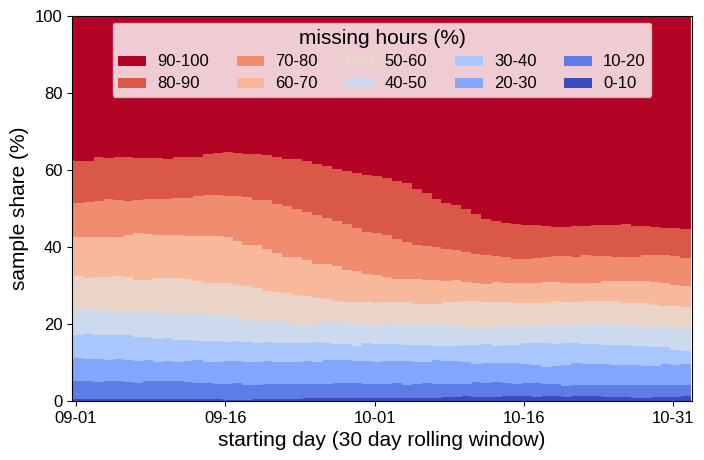

In [79]:
fig, ax = plt.subplots(figsize=(8,5))

dr = pd.date_range(start = dt.date(2024, 9, 1), end = dt.date(2024,11,2))

viz_coverage(ax,
             cov_share_sw, 
             date_range= _dr,
             sws = 30,
             date_step = 30)

# --- reverse legend order ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          title="missing hours (%)",
          #bbox_to_anchor=(1.05, .5),
          loc='upper center',
          ncols=5)
#ax.set_title('Sliding window of 30 days')
ax.set_title('')
ax.set_ylim(0,1)
convert_mmdd_to_ddmon(ax)
ax.tick_params(axis = 'x', rotation = 0)
set_percent_yticks(ax, decimals = 0)

ax.set_ylabel("sample share (%)")
ax.set_xlabel("starting day (30 day rolling window)")

restyle_ax(ax, title_size = config.ax_label_size)

#### [supp panel] Epidemic curves from biased and rescaled contacts

## Display of Figures with description